# Flow Matching: Condition Number Analysis with Power Law Investigation

This notebook investigates the condition number behavior when generating samples from a trained Flow Matching model.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import sys
sys.path.append('../')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm
import torch
import torch.nn as nn
from torch import optim

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
from src.datasets import build_true_matrix, simulate_from_covariance_mean
from src.models.flow_matching.base import FlowMatchingModel

/usr/lib/python3/dist-packages/sklearn/utils/fixes.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


In [5]:
# Automatic GPU detection
device = "cuda" if torch.cuda.is_available() else "cpu"

print("="*60)
print("DEVICE CONFIGURATION")
print("="*60)
print(f"Using device: {device.upper()}")

if device == "cuda":
    print(f"\n✓ GPU detected and enabled!")
    print(f"  GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"\n✓ Optimized batch generation enabled")
    print(f"  Flow Matching calls reduced: 5,600 → 28 (200x fewer!)")
    print(f"  Combined speedup: ~50-100x faster than naive CPU approach")
    print(f"\nEstimated total runtime: ~5-15 minutes")
else:
    print(f"\n⚠ No GPU detected - using CPU")
    print(f"  Flow Matching sampling will be slower, but still optimized")
    print(f"\n✓ Optimized batch generation enabled")
    print(f"  Flow Matching calls reduced: 5,600 → 28 (200x fewer!)")
    print(f"  Speedup: ~5-10x faster than naive approach")
    print(f"\nEstimated total runtime: ~30-60 minutes")
    print(f"\nTo use GPU for additional 10-20x speedup:")
    print(f"  1. Ensure you have a CUDA-capable GPU")
    print(f"  2. Install PyTorch with CUDA support")
    print(f"  3. Restart the kernel")

print("="*60)

DEVICE CONFIGURATION
Using device: CUDA

✓ GPU detected and enabled!
  GPU Name: NVIDIA GH200 480GB
  GPU Memory: 101.47 GB
  CUDA Version: 12.8

✓ Optimized batch generation enabled
  Flow Matching calls reduced: 5,600 → 28 (200x fewer!)
  Combined speedup: ~50-100x faster than naive CPU approach

Estimated total runtime: ~5-15 minutes


## 1. Generate True Covariance Matrix and Compute cond_0

In [6]:
# Set random seed for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Parameters for the true covariance matrix
number_blocks = 5
block_size = 10
block_correlation = 0.5

# Build the true covariance matrix
true_mu, true_covariance = build_true_matrix(
    number_blocks=number_blocks,
    block_size=block_size,
    block_correlation=block_correlation
)

input_dimension = number_blocks * block_size

print(f"Covariance matrix shape: {true_covariance.shape}")
print(f"Mean vector shape: {true_mu.shape}")
print(f"Input dimension: {input_dimension}")

Covariance matrix shape: (50, 50)
Mean vector shape: (50, 1)
Input dimension: 50


In [7]:
# Compute the condition number of the true covariance matrix
cond_0 = np.linalg.cond(true_covariance)
print(f"Condition number of true covariance (cond_0): {cond_0:.4f}")

Condition number of true covariance (cond_0): 91.0112


## 2. Generate Training Data (10,000 samples)

In [8]:
# Generate 10,000 samples from the true covariance for training
number_training_samples = 10000

print(f"Generating {number_training_samples} training samples...")
training_data, sample_mu, sample_covariance = simulate_from_covariance_mean(
    true_mu=true_mu,
    true_covariance=true_covariance,
    number_of_observations=number_training_samples
)

training_data = training_data.astype(np.float32)

print(f"Training data shape: {training_data.shape}")
print(f"Training data mean: {training_data.mean(axis=0)[:5]}...")
print(f"Training data std: {training_data.std(axis=0)[:5]}...")

Generating 10000 training samples...
Training data shape: (10000, 50)
Training data mean: [0.050906   0.05213005 0.04773158 0.04168098 0.06322674]...
Training data std: [0.07017788 0.09766946 0.0730627  0.08355759 0.10729335]...


## 3. Train the Flow Matching Model

In [9]:
# Convert training data to tensor
training_data_tensor = torch.tensor(training_data, dtype=torch.float32).to(device)

# Initialize the flow matching model
flow_model = FlowMatchingModel(
    input_dimension=input_dimension,
    number_of_layers=3,
    hidden_dimension=384,
    time_dimension=256,
    learning_rate=1e-4
).to(device)

print(f"Model has {sum(p.numel() for p in flow_model.parameters())} parameters")

Model has 581042 parameters


In [10]:
# Train the model
print("\nTraining Flow Matching model...")
flow_model.fit(
    data=training_data_tensor,
    training_steps=2500,
    batch_size=128
)

print(f"Training complete. Final loss: {flow_model.losses[-1]:.6f}")


Training Flow Matching model...
Epoch 100/2500, Loss: 0.8606
Epoch 200/2500, Loss: 0.5432
Epoch 300/2500, Loss: 0.3923
Epoch 400/2500, Loss: 0.3043
Epoch 500/2500, Loss: 0.2697
Epoch 600/2500, Loss: 0.3014
Epoch 700/2500, Loss: 0.2910
Epoch 800/2500, Loss: 0.2608
Epoch 900/2500, Loss: 0.2211
Epoch 1000/2500, Loss: 0.2431
Epoch 1100/2500, Loss: 0.2117
Epoch 1200/2500, Loss: 0.2189
Epoch 1300/2500, Loss: 0.2653
Epoch 1400/2500, Loss: 0.2661
Epoch 1500/2500, Loss: 0.2414
Epoch 1600/2500, Loss: 0.2602
Epoch 1700/2500, Loss: 0.2694
Epoch 1800/2500, Loss: 0.2370
Epoch 1900/2500, Loss: 0.2290
Epoch 2000/2500, Loss: 0.1927
Epoch 2100/2500, Loss: 0.2456
Epoch 2200/2500, Loss: 0.2506
Epoch 2300/2500, Loss: 0.2071
Epoch 2400/2500, Loss: 0.2433
Epoch 2500/2500, Loss: 0.2238
Training complete. Final loss: 0.223808


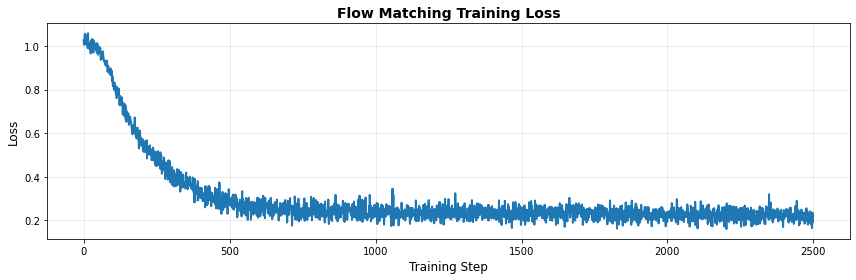

In [11]:
# Plot training loss
plt.figure(figsize=(12, 4))
plt.plot(flow_model.losses, linewidth=2)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Flow Matching Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Generate Samples from Flow Matching Model with Varying Sample Sizes

In [12]:
# Define sample sizes to test
sample_sizes = list(range(100, 1000, 100)) + list(range(1000, 10001, 500))

# Number of replications for each sample size
num_replications = 200

print(f"Testing {len(sample_sizes)} sample sizes: {sample_sizes}")
print(f"Running {num_replications} replications for each sample size")
print(f"Total experiments: {len(sample_sizes) * num_replications}")

Testing 28 sample sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000]
Running 200 replications for each sample size
Total experiments: 5600


In [13]:
# Storage for results
results = {
    'sample_size': [],
    'cond_n_median': [],
    'cond_n_q25': [],
    'cond_n_q75': [],
    'cond_n_mean': [],
    'cond_n_std': [],
    'ratio_median': [],  # This will be used for power law analysis
    'ratio_q25': [],
    'ratio_q75': [],
    'ratio_mean': [],
    'ratio_std': []
}

# Run the experiment with optimized batch generation
print("Generating samples from Flow Matching and computing condition numbers...")
print("Using optimized batch generation for speed...\n")

for n in tqdm(sample_sizes, desc="Sample sizes"):
    # OPTIMIZATION: Generate all replications at once (much faster!)
    # Instead of calling flow_model.sample() 200 times, call it once with n*200 samples
    total_samples_needed = n * num_replications
    
    print(f"\n  Generating {total_samples_needed} samples ({num_replications} batches of {n})...")
    all_generated_samples = flow_model.sample(
        number_samples=total_samples_needed,
        number_steps=1000,
        seed=42
    ).cpu().numpy()
    
    # Storage for replications
    cond_n_replications = []
    ratio_replications = []
    
    # Split the generated samples into replications
    print(f"  Computing condition numbers for {num_replications} replications...")
    for r in range(num_replications):
        # Extract samples for this replication
        start_idx = r * n
        end_idx = (r + 1) * n
        generated_samples = all_generated_samples[start_idx:end_idx]
        
        # Compute sample covariance matrix
        sample_cov = pd.DataFrame(generated_samples).cov().values
        
        # Compute condition number of sample covariance
        cond_n = np.linalg.cond(sample_cov)
        
        # Compute ratio
        ratio = cond_n / cond_0
        
        # Store replication results
        cond_n_replications.append(cond_n)
        ratio_replications.append(ratio)
    
    # Compute statistics across replications
    results['sample_size'].append(n)
    results['cond_n_median'].append(np.median(cond_n_replications))
    results['cond_n_q25'].append(np.percentile(cond_n_replications, 25))
    results['cond_n_q75'].append(np.percentile(cond_n_replications, 75))
    results['cond_n_mean'].append(np.mean(cond_n_replications))
    results['cond_n_std'].append(np.std(cond_n_replications))
    
    results['ratio_median'].append(np.median(ratio_replications))
    results['ratio_q25'].append(np.percentile(ratio_replications, 25))
    results['ratio_q75'].append(np.percentile(ratio_replications, 75))
    results['ratio_mean'].append(np.mean(ratio_replications))
    results['ratio_std'].append(np.std(ratio_replications))

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("SAMPLING COMPLETE")
print("="*60)
print("\nFirst few results:")
print(results_df[['sample_size', 'cond_n_median', 'ratio_median', 'ratio_q25', 'ratio_q75']].head())
print("\nLast few results:")
print(results_df[['sample_size', 'cond_n_median', 'ratio_median', 'ratio_q25', 'ratio_q75']].tail())

Generating samples from Flow Matching and computing condition numbers...
Using optimized batch generation for speed...



Sample sizes:   0%|          | 0/28 [00:00<?, ?it/s]


  Generating 20000 samples (200 batches of 100)...


Sample sizes:   4%|▎         | 1/28 [00:00<00:21,  1.24it/s]

Done Sampling
  Computing condition numbers for 200 replications...

  Generating 40000 samples (200 batches of 200)...


...


  Generating 1900000 samples (200 batches of 9500)...
Done Sampling
  Computing condition numbers for 200 replications...


Sample sizes:  96%|█████████▋| 27/28 [10:28<00:52, 52.61s/it]


  Generating 2000000 samples (200 batches of 10000)...
Done Sampling
  Computing condition numbers for 200 replications...


Sample sizes: 100%|██████████| 28/28 [11:31<00:00, 24.70s/it]


SAMPLING COMPLETE

First few results:
   sample_size  cond_n_median  ratio_median  ratio_q25  ratio_q75
0          100      75.220310      0.826495   0.737132   0.955399
1          200      25.859264      0.284133   0.261928   0.303826
2          300      18.295664      0.201027   0.190951   0.213078
3          400      15.432954      0.169572   0.160698   0.179347
4          500      14.017343      0.154018   0.147335   0.161712

Last few results:
    sample_size  cond_n_median  ratio_median  ratio_q25  ratio_q75
23         8000       9.191302      0.100991   0.099725   0.102718
24         8500       9.178636      0.100852   0.099733   0.102583
25         9000       9.163963      0.100691   0.099553   0.102144
26         9500       9.144081      0.100472   0.099260   0.101948
27        10000       9.150348      0.100541   0.099188   0.101845


## 5. Visualize the Results

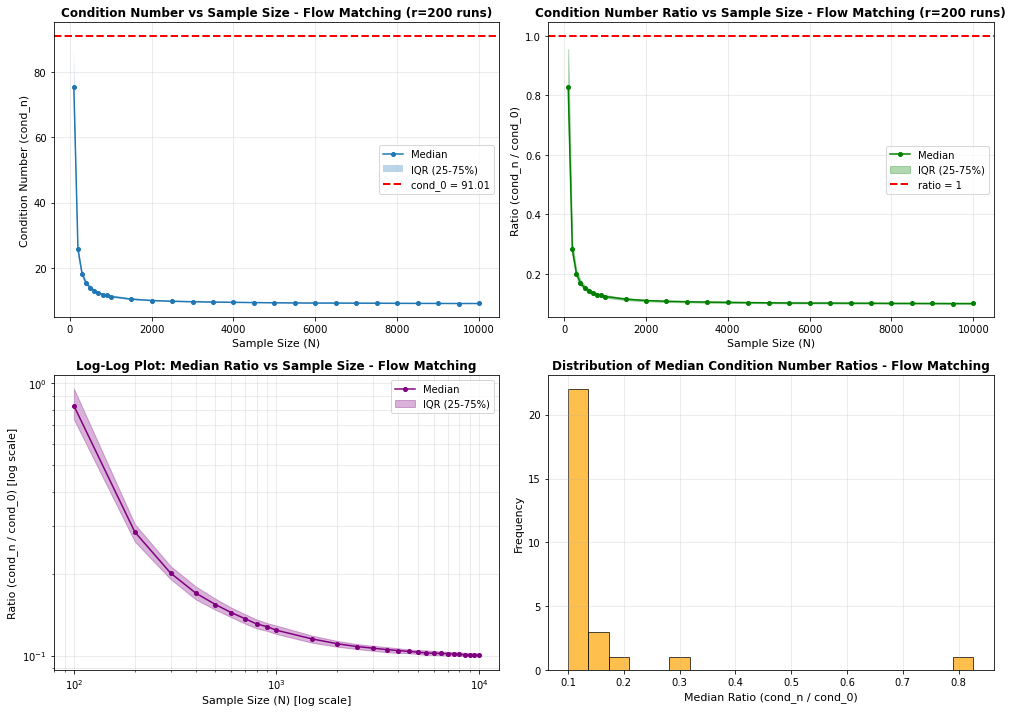

In [14]:
# Plot the condition numbers with median and quartiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: cond_n vs sample size (with quartiles)
axes[0, 0].plot(results_df['sample_size'].values, results_df['cond_n_median'].values, 'o-', markersize=4, label='Median')
axes[0, 0].fill_between(results_df['sample_size'], 
                         results_df['cond_n_q25'], 
                         results_df['cond_n_q75'], 
                         alpha=0.3, label='IQR (25-75%)')
axes[0, 0].axhline(y=cond_0, color='r', linestyle='--', label=f'cond_0 = {cond_0:.2f}', linewidth=2)
axes[0, 0].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 0].set_ylabel('Condition Number (cond_n)', fontsize=11)
axes[0, 0].set_title(f'Condition Number vs Sample Size - Flow Matching (r={num_replications} runs)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Ratio (cond_n / cond_0) vs sample size (with quartiles)
axes[0, 1].plot(results_df['sample_size'].values, results_df['ratio_median'].values, 'o-', markersize=4, color='green', label='Median')
axes[0, 1].fill_between(results_df['sample_size'], 
                         results_df['ratio_q25'], 
                         results_df['ratio_q75'], 
                         alpha=0.3, color='green', label='IQR (25-75%)')
axes[0, 1].axhline(y=1, color='r', linestyle='--', label='ratio = 1', linewidth=2)
axes[0, 1].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 1].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
axes[0, 1].set_title(f'Condition Number Ratio vs Sample Size - Flow Matching (r={num_replications} runs)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Log-log plot (for power law detection)
axes[1, 0].loglog(results_df['sample_size'].values, results_df['ratio_median'].values, 'o-', markersize=4, color='purple', label='Median')
axes[1, 0].fill_between(results_df['sample_size'], 
                         results_df['ratio_q25'], 
                         results_df['ratio_q75'], 
                         alpha=0.3, color='purple', label='IQR (25-75%)')
axes[1, 0].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
axes[1, 0].set_ylabel('Ratio (cond_n / cond_0) [log scale]', fontsize=11)
axes[1, 0].set_title('Log-Log Plot: Median Ratio vs Sample Size - Flow Matching', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')

# Plot 4: Distribution of median ratios
axes[1, 1].hist(results_df['ratio_median'].values, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Median Ratio (cond_n / cond_0)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Median Condition Number Ratios - Flow Matching', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Power Law Analysis

In [15]:
# Fit a power law: ratio_median = a * N^b
# Taking log: log(ratio_median) = log(a) + b * log(N)

from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.power(x, b)

# Fit the power law using median values
params, covariance = curve_fit(
    power_law,
    results_df['sample_size'],
    results_df['ratio_median'],
    p0=[1, -0.5]  # Initial guess: ratio decreases with sample size
)

a_fit, b_fit = params
print(f"\nPower Law Fit (using median across {num_replications} runs):")
print(f"  ratio_median = {a_fit:.4f} * N^{b_fit:.4f}")
print(f"\nParameter uncertainties:")
print(f"  a: {np.sqrt(covariance[0, 0]):.4f}")
print(f"  b: {np.sqrt(covariance[1, 1]):.4f}")


Power Law Fit (using median across 200 runs):
  ratio_median = 18.4165 * N^-0.7163

Parameter uncertainties:
  a: 7.7545
  b: 0.0771


In [16]:
# Compute R-squared to assess fit quality
fitted_values = power_law(results_df['sample_size'], a_fit, b_fit)
residuals = results_df['ratio_median'] - fitted_values
ss_res = np.sum(residuals**2)
ss_tot = np.sum((results_df['ratio_median'] - np.mean(results_df['ratio_median']))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nGoodness of Fit:")
print(f"  R-squared: {r_squared:.4f}")
print(f"  RMSE: {np.sqrt(np.mean(residuals**2)):.4f}")


Goodness of Fit:
  R-squared: 0.7451
  RMSE: 0.0687


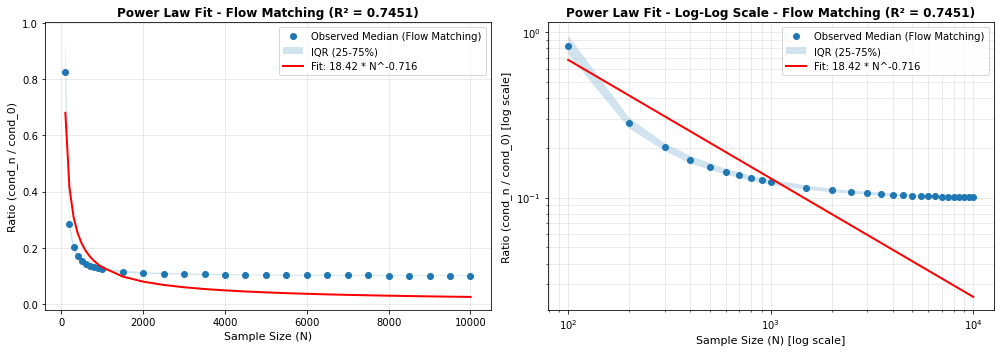

In [17]:
# Visualize the fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(results_df['sample_size'].values, results_df['ratio_median'].values, 'o', label='Observed Median (Flow Matching)', markersize=6)
axes[0].fill_between(results_df['sample_size'], 
                      results_df['ratio_q25'], 
                      results_df['ratio_q75'], 
                      alpha=0.2, label='IQR (25-75%)')
axes[0].plot(results_df['sample_size'].values, fitted_values.values, '-', label=f'Fit: {a_fit:.2f} * N^{b_fit:.3f}', linewidth=2, color='red')
axes[0].set_xlabel('Sample Size (N)', fontsize=11)
axes[0].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
axes[0].set_title(f'Power Law Fit - Flow Matching (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Log-log scale
axes[1].loglog(results_df['sample_size'].values, results_df['ratio_median'].values, 'o', label='Observed Median (Flow Matching)', markersize=6)
axes[1].fill_between(results_df['sample_size'], 
                      results_df['ratio_q25'], 
                      results_df['ratio_q75'], 
                      alpha=0.2, label='IQR (25-75%)')
axes[1].loglog(results_df['sample_size'].values, fitted_values.values, '-', 
               label=f'Fit: {a_fit:.2f} * N^{b_fit:.3f}', linewidth=2, color='red')
axes[1].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
axes[1].set_ylabel('Ratio (cond_n / cond_0) [log scale]', fontsize=11)
axes[1].set_title(f'Power Law Fit - Log-Log Scale - Flow Matching (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 7. Statistical Tests for Power Law

In [18]:
# Linear regression on log-transformed data (using median values)
log_N = np.log(results_df['sample_size'])
log_ratio_median = np.log(results_df['ratio_median'])

# Perform linear regression
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(log_N, log_ratio_median)

print("="*60)
print("LINEAR REGRESSION ON LOG-TRANSFORMED DATA")
print("="*60)
print(f"Using median ratios across {num_replications} replications\n")
print(f"  log(ratio_median) = {intercept:.4f} + {slope:.4f} * log(N)")
print(f"  Which implies: ratio_median = {np.exp(intercept):.4f} * N^{slope:.4f}")
print(f"\n  R-squared: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Standard error: {std_err:.4f}")

if p_value < 0.001:
    print(f"\n✓ The relationship is highly significant (p < 0.001)")
elif p_value < 0.05:
    print(f"\n✓ The relationship is significant (p < 0.05)")
else:
    print(f"\n✗ The relationship is not significant (p >= 0.05)")

LINEAR REGRESSION ON LOG-TRANSFORMED DATA
Using median ratios across 200 replications

  log(ratio_median) = 0.0430 + -0.2739 * log(N)
  Which implies: ratio_median = 1.0439 * N^-0.2739

  R-squared: 0.6778
  p-value: 0.000000
  Standard error: 0.0370

✓ The relationship is highly significant (p < 0.001)


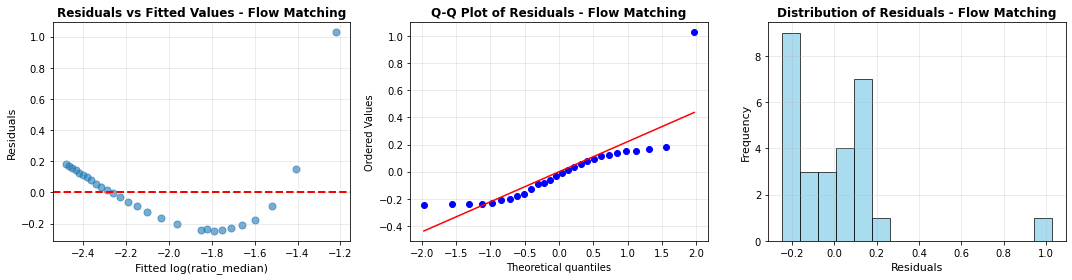

In [19]:
# Residual analysis
log_fitted = intercept + slope * log_N
log_residuals = log_ratio_median - log_fitted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs fitted
axes[0].scatter(log_fitted, log_residuals, alpha=0.6, s=50)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted log(ratio_median)', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values - Flow Matching', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(log_residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals - Flow Matching', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Histogram of residuals
axes[2].hist(log_residuals, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[2].set_xlabel('Residuals', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Distribution of Residuals - Flow Matching', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Comparison: Flow Matching vs Training Data

In [20]:
# Compute condition number of training data covariance
training_cov = pd.DataFrame(training_data).cov().values
training_cond = np.linalg.cond(training_cov)
training_ratio = training_cond / cond_0

print("="*60)
print("COMPARISON: FLOW MATCHING SAMPLES vs TRAINING DATA")
print("="*60)
print(f"\nTraining data (N={number_training_samples}):")
print(f"  Condition number: {training_cond:.4f}")
print(f"  Ratio (cond/cond_0): {training_ratio:.4f}")
print(f"\nFlow Matching samples at N={number_training_samples} (if available):")
if number_training_samples in results_df['sample_size'].values:
    fm_row = results_df[results_df['sample_size'] == number_training_samples].iloc[0]
    print(f"  Condition number: {fm_row['cond_n_median']:.4f}")
    print(f"  Ratio (cond/cond_0): {fm_row['ratio_median']:.4f}")
    print(f"\nDifference:")
    print(f"  Flow Matching ratio / Training ratio = {fm_row['ratio_median'] / training_ratio:.4f}")
else:
    print(f"  Not tested at exactly N={number_training_samples}")
    # Find closest sample size
    closest_idx = np.argmin(np.abs(results_df['sample_size'] - number_training_samples))
    closest_row = results_df.iloc[closest_idx]
    print(f"  Closest tested: N={closest_row['sample_size']}")
    print(f"    Condition number: {closest_row['cond_n_median']:.4f}")
    print(f"    Ratio (cond/cond_0): {closest_row['ratio_median']:.4f}")

COMPARISON: FLOW MATCHING SAMPLES vs TRAINING DATA

Training data (N=10000):
  Condition number: 93.8085
  Ratio (cond/cond_0): 1.0307

Flow Matching samples at N=10000 (if available):
  Condition number: 9.1503
  Ratio (cond/cond_0): 0.1005

Difference:
  Flow Matching ratio / Training ratio = 0.0975


## 9. Summary Statistics

In [21]:
print("="*60)
print("SUMMARY OF RESULTS")
print("="*60)
print(f"\nTrue covariance condition number (cond_0): {cond_0:.4f}")
print(f"\nTraining:")
print(f"  Number of samples: {number_training_samples}")
print(f"  Number of training steps: 2500")
print(f"  Final training loss: {flow_model.losses[-1]:.6f}")
print(f"\nExperimental Design:")
print(f"  Number of sample sizes tested: {len(sample_sizes)}")
print(f"  Sample size range: {min(sample_sizes)} to {max(sample_sizes)}")
print(f"  Replications per sample size: {num_replications}")
print(f"  Total experiments: {len(sample_sizes) * num_replications}")
print(f"\nCondition number statistics (median across replications):")
print(f"  Min: {results_df['cond_n_median'].min():.4f}")
print(f"  Max: {results_df['cond_n_median'].max():.4f}")
print(f"  Mean: {results_df['cond_n_median'].mean():.4f}")
print(f"  Std: {results_df['cond_n_median'].std():.4f}")
print(f"\nRatio statistics (median cond_n / cond_0):")
print(f"  Min: {results_df['ratio_median'].min():.4f}")
print(f"  Max: {results_df['ratio_median'].max():.4f}")
print(f"  Mean: {results_df['ratio_median'].mean():.4f}")
print(f"  Std: {results_df['ratio_median'].std():.4f}")
print(f"\nVariability across replications (average IQR):")
print(f"  Avg IQR for cond_n: {(results_df['cond_n_q75'] - results_df['cond_n_q25']).mean():.4f}")
print(f"  Avg IQR for ratio: {(results_df['ratio_q75'] - results_df['ratio_q25']).mean():.4f}")
print(f"\nPower Law Fit Results (on median values):")
print(f"  Formula: ratio_median = {a_fit:.4f} * N^{b_fit:.4f}")
print(f"  R-squared: {r_squared:.4f}")
print(f"  Exponent (b): {b_fit:.4f} ± {np.sqrt(covariance[1, 1]):.4f}")
print(f"\nLinear Regression on Log-Transformed Data:")
print(f"  Formula: ratio_median ≈ {np.exp(intercept):.4f} * N^{slope:.4f}")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")

# Interpretation
print(f"\n" + "="*60)
print("INTERPRETATION")
print("="*60)
if r_squared > 0.9:
    print("✓ The data shows a STRONG power law relationship")
elif r_squared > 0.7:
    print("✓ The data shows a MODERATE power law relationship")
else:
    print("✗ The data shows a WEAK power law relationship")

if b_fit < 0:
    print(f"✓ The ratio DECREASES as sample size increases (exponent = {b_fit:.4f})")
    print(f"  This means Flow Matching-generated samples become relatively better conditioned with more samples")
else:
    print(f"✗ The ratio INCREASES as sample size increases (exponent = {b_fit:.4f})")
    print(f"  This means Flow Matching-generated samples become relatively worse conditioned with more samples")

# Compare with true covariance
avg_ratio = results_df['ratio_median'].mean()
if avg_ratio < 1:
    print(f"\n✓ On average, Flow Matching samples have BETTER conditioning than the true covariance")
    print(f"  Average ratio: {avg_ratio:.4f} (< 1)")
elif avg_ratio > 1:
    print(f"\n✗ On average, Flow Matching samples have WORSE conditioning than the true covariance")
    print(f"  Average ratio: {avg_ratio:.4f} (> 1)")
else:
    print(f"\n≈ On average, Flow Matching samples have SIMILAR conditioning to the true covariance")
    print(f"  Average ratio: {avg_ratio:.4f} (≈ 1)")

# Convergence analysis
if results_df['ratio_median'].iloc[-1] < 1.1 and results_df['ratio_median'].iloc[-1] > 0.9:
    print(f"\n✓ The ratio converges to approximately 1 at large N (N={max(sample_sizes)})")
    print(f"  Final ratio: {results_df['ratio_median'].iloc[-1]:.4f}")
else:
    print(f"\n✗ The ratio does not converge to 1 at N={max(sample_sizes)}")
    print(f"  Final ratio: {results_df['ratio_median'].iloc[-1]:.4f}")

SUMMARY OF RESULTS

True covariance condition number (cond_0): 91.0112

Training:
  Number of samples: 10000
  Number of training steps: 2500
  Final training loss: 0.223808

Experimental Design:
  Number of sample sizes tested: 28
  Sample size range: 100 to 10000
  Replications per sample size: 200
  Total experiments: 5600

Condition number statistics (median across replications):
  Min: 9.1441
  Max: 75.2203
  Mean: 13.5444
  Std: 12.6181

Ratio statistics (median cond_n / cond_0):
  Min: 0.1005
  Max: 0.8265
  Mean: 0.1488
  Std: 0.1386

Variability across replications (average IQR):
  Avg IQR for cond_n: 1.4062
  Avg IQR for ratio: 0.0155

Power Law Fit Results (on median values):
  Formula: ratio_median = 18.4165 * N^-0.7163
  R-squared: 0.7451
  Exponent (b): -0.7163 ± 0.0771

Linear Regression on Log-Transformed Data:
  Formula: ratio_median ≈ 1.0439 * N^-0.2739
  R-squared: 0.6778
  p-value: 0.000000

INTERPRETATION
✓ The data shows a MODERATE power law relationship
✓ The rat

In [22]:
# Save results with all statistics
results_df.to_csv('flow_matching_condition_number_results.csv', index=False)
print("\n" + "="*60)
print("Results saved to 'flow_matching_condition_number_results.csv'")
print("="*60)
print("\nSaved columns:")
print("  - sample_size: Number of samples generated from Flow Matching")
print("  - cond_n_median: Median condition number across replications")
print("  - cond_n_q25: 25th percentile of condition numbers")
print("  - cond_n_q75: 75th percentile of condition numbers")
print("  - cond_n_mean: Mean condition number across replications")
print("  - cond_n_std: Standard deviation of condition numbers")
print("  - ratio_median: Median of cond_n/cond_0 (used for power law)")
print("  - ratio_q25: 25th percentile of ratios")
print("  - ratio_q75: 75th percentile of ratios")
print("  - ratio_mean: Mean of ratios")
print("  - ratio_std: Standard deviation of ratios")


Results saved to 'flow_matching_condition_number_results.csv'

Saved columns:
  - sample_size: Number of samples generated from Flow Matching
  - cond_n_median: Median condition number across replications
  - cond_n_q25: 25th percentile of condition numbers
  - cond_n_q75: 75th percentile of condition numbers
  - cond_n_mean: Mean condition number across replications
  - cond_n_std: Standard deviation of condition numbers
  - ratio_median: Median of cond_n/cond_0 (used for power law)
  - ratio_q25: 25th percentile of ratios
  - ratio_q75: 75th percentile of ratios
  - ratio_mean: Mean of ratios
  - ratio_std: Standard deviation of ratios


## 10. Additional Analysis: Quality Check

Generating 5000 samples for quality check...
Done Sampling


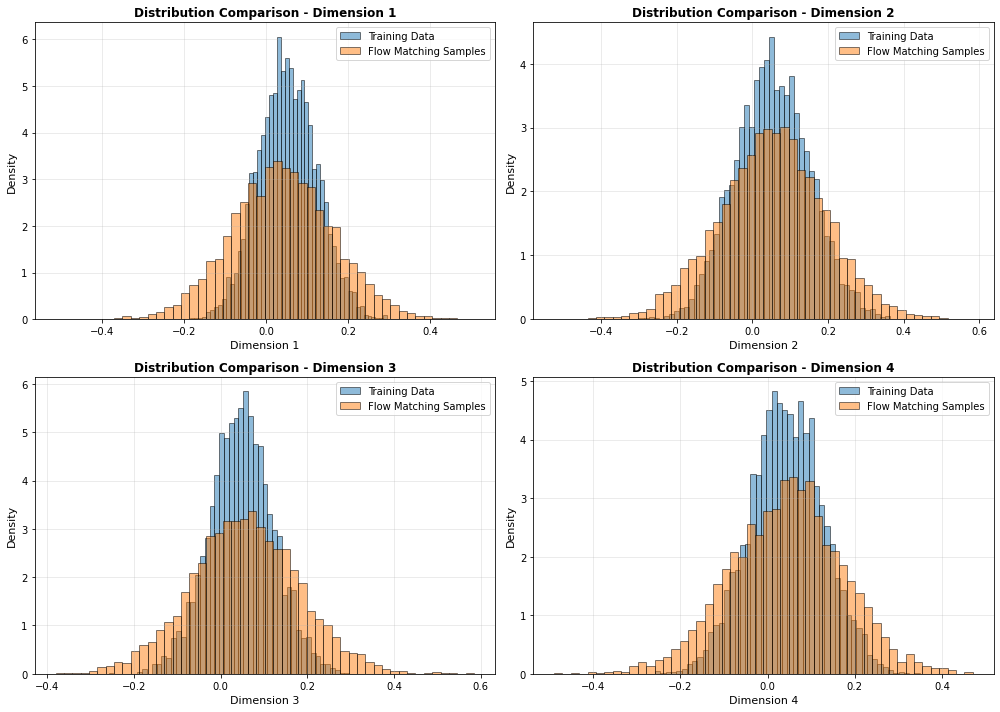


Mean comparison (first 5 dimensions):
  Training data: [0.05180526 0.05244087 0.04782886 0.04237191 0.06300768]
  Flow Matching samples:  [0.0389456  0.05109069 0.05635469 0.0425854  0.0750624 ]

Std comparison (first 5 dimensions):
  Training data: [0.07075646 0.09809433 0.07347683 0.0841678  0.10723661]
  Flow Matching samples:  [0.12352089 0.13953328 0.12475082 0.12944494 0.14427352]


In [23]:
# Generate a large sample for quality check
print("Generating 5000 samples for quality check...")
large_sample = flow_model.sample(
    number_samples=5000,
    number_steps=1000,
    seed=123
).cpu().numpy()

# Compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Compare marginal distributions for first few dimensions
for i in range(4):
    row = i // 2
    col = i % 2
    
    axes[row, col].hist(training_data[:5000, i], bins=50, alpha=0.5, label='Training Data', 
                        density=True, edgecolor='black')
    axes[row, col].hist(large_sample[:, i], bins=50, alpha=0.5, label='Flow Matching Samples', 
                        density=True, edgecolor='black')
    axes[row, col].set_xlabel(f'Dimension {i+1}', fontsize=11)
    axes[row, col].set_ylabel('Density', fontsize=11)
    axes[row, col].set_title(f'Distribution Comparison - Dimension {i+1}', 
                             fontsize=12, fontweight='bold')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean comparison (first 5 dimensions):")
print(f"  Training data: {training_data[:5000, :5].mean(axis=0)}")
print(f"  Flow Matching samples:  {large_sample[:, :5].mean(axis=0)}")
print(f"\nStd comparison (first 5 dimensions):")
print(f"  Training data: {training_data[:5000, :5].std(axis=0)}")
print(f"  Flow Matching samples:  {large_sample[:, :5].std(axis=0)}")